# 9. The model against a real market: Polymarket Bitcoin touch contracts

**What this notebook answers:** we have a calibrated model (notebook 8). What does it say about the
Bitcoin "will it hit $X?" contracts that are live on Polymarket *right now*, where does it disagree
with the crowd, and what would it take for that disagreement to be a trade?

**Read this first.**

* This is a **single snapshot** taken when the notebook was built (saved in `notebooks/data/live_snapshot.json`, so it re-runs identically). One snapshot proves nothing about profitability.
* The backtest in notebook 8 showed the model prices better than a *rule of thumb*. It did **not** compare against a market. This notebook only *looks*; the running system (`make up`) records every cycle so that comparison can be made properly, with resolved contracts, over time.
* Everything is **paper only**: no orders are ever placed.

In [1]:
import sys, json
sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import _style as st
from pmq.risk import kelly
from pmq.pricing import fees

st.setup()
snap = json.load(open("data/live_snapshot.json"))
df = pd.DataFrame(snap["rows"])
print("snapshot taken:", snap["as_of"][:19], "UTC | model:", snap["model_id"])

snapshot taken: 2026-09-21T21:46:57 UTC | model: har_mix-XBT-8bd1c859


## 9.1 A lesson in resolution sources: $107 that flipped a contract

Polymarket settles "will Bitcoin hit $X?" on the **high/low of Binance BTC/USDT 1-minute candles**. My tick data, and the first version of the live pricer, used **Kraken** BTC/USD. They are the "same" price only to within a small **basis**, and for a barrier that sits within that basis of the running extreme, the basis is the whole question.

A real example from this build: the contract *"Will Bitcoin dip to $75,000 in September?"* had a fresh version listed on 16 September at 16:17 UTC.
The lowest prices seen in the following hours were:

| Source | Lowest low, 16 Sep 18:00 UTC hour | Touched $75,000? |
|---|---|---|
| Kraken BTC/USD | $74,957.20 | **yes** ($43 through) |
| Binance BTC/USDT (the settlement source) | $75,064.82 | **no** ($65 short) |

The market priced it at about 5.5% (correctly: it had not touched on Binance). The Kraken-based model called it **certain** and printed a 94-point "edge". That is not an opportunity, it is a data-source bug, and the fix (now in the code) is to run barrier checks on the venue's own source.
Three lessons that generalise:

1. A model can be right about the maths and wrong about the *rules of the contract*. **Reading the resolution criteria is part of the model.**
2. Very large "edges" are more likely to be bugs than gifts. The pricer counts any edge above 25 points as *suspicious* and the dashboard shows the count.
3. The Kraken-versus-Binance gap is now a **monitored metric** (`pmq_spot_basis_bps`), with an alert if it exceeds 30 bps.

A second quirk found the same way: when a strike is touched, Polymarket resolves that market and **lists a fresh one at the same strike**, which only counts touches after *its own* start time. Using the event's start date instead of the market's would make every re-listed strike look already hit.

## 9.2 Model versus market, strike by strike

19 open contracts in the nearest-expiry event (9.3 days left); spot $86,723


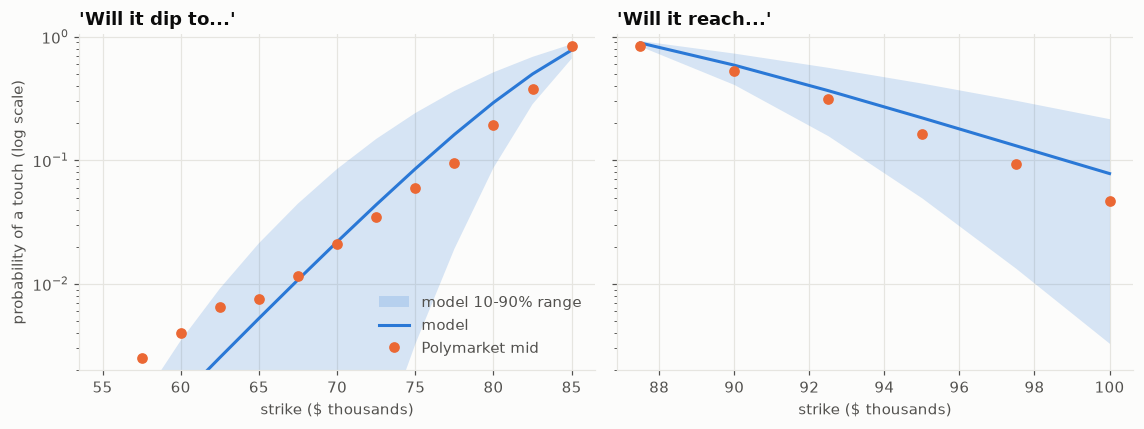

In [2]:
open_ = df[(~df["already_touched"]) & df["mid"].notna()].copy()
nearest = open_["days_left"].round(1).min()
ev = open_[open_["days_left"].round(1) == nearest].copy()
print(f"{len(ev)} open contracts in the nearest-expiry event ({nearest} days left); spot ${ev['spot'].iloc[0]:,.0f}")

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4), sharey=True)
for ax, direction, title in [(axes[0], "down", "'Will it dip to...'"), (axes[1], "up", "'Will it reach...'")]:
    d = ev[ev["direction"] == direction].sort_values("barrier")
    ax.fill_between(d["barrier"] / 1000, d["p_low"], d["p_high"], color=st.BLUE, alpha=0.18, lw=0, label="model 10-90% range")
    ax.plot(d["barrier"] / 1000, d["p"], "-", color=st.BLUE, label="model")
    ax.plot(d["barrier"] / 1000, d["mid"], "o", color=st.ORANGE, ms=6, label="Polymarket mid")
    ax.set_title(title); ax.set_xlabel("strike ($ thousands)"); ax.set_yscale("log"); ax.set_ylim(0.002, 1.05)
axes[0].set_ylabel("probability of a touch (log scale)"); axes[0].legend(loc="lower right")
plt.tight_layout(); plt.show()

Two patterns stand out:

* **Near the money (within roughly 10% of spot) the model is above the market** on both the dips and the rallies, and on the rally side it is above the market at *every* strike.
* **On the far downside the market is above the model.** The crowd pays more for very deep dips (a $57,500 dip trades at 0.2% against the model's 0.05%) than the model allows.

The market mid falls inside the model's 10-90% range for about 84% of these contracts (74% across all open contracts), so the disagreement is modest relative to the model's own uncertainty. Gaps of different sign at different strikes are not a single directional view: they are a disagreement about the **shape of Bitcoin's volatility**. That is exactly what the next section measures.

## 9.3 The market's volatility: implied volatility from prediction prices

Options traders quote prices as an *implied volatility*: the volatility that makes a pricing formula reproduce the market price. We can do the same for a touch contract by inverting the barrier formula of notebook 4 (`pmq.crypto.barrier.implied_volatility`, with the 1-minute monitoring correction).

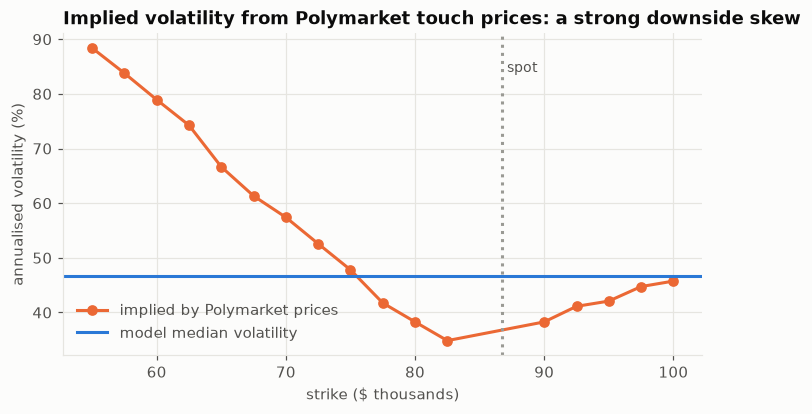

mid      p  implied_vol  sigma_median
direction barrier                                          
down      55000.0   0.002  0.000        0.884         0.467
          57500.0   0.002  0.001        0.838         0.467
          60000.0   0.004  0.001        0.789         0.467
          62500.0   0.007  0.003        0.743         0.467
          65000.0   0.008  0.005        0.666         0.467
          67500.0   0.012  0.011        0.613         0.467
          70000.0   0.021  0.022        0.574         0.467
          72500.0   0.035  0.044        0.526         0.467
          75000.0   0.060  0.085        0.478         0.467
          77500.0   0.095  0.162        0.417         0.467
          80000.0   0.192  0.293        0.383         0.467
          82500.0   0.375  0.500        0.349         0.467
          85000.0   0.840  0.780        0.607         0.467
up        87500.0   0.845  0.891        0.302         0.467
          90000.0   0.530  0.589        0.383         0.467
          92500.0   0.312  0.367        0.411         0.467
          95000.0   0.164  0.221        0.421         0.467
          97500.0   0.094  0.131        0.447         0.467
          100000.0  0.046  0.078        0.457         0.467

In [3]:
ev = ev.sort_values("barrier")
# A barrier within ~3% of spot makes the inversion ill-conditioned (the price is almost 1 and the
# 1-minute monitoring shift dominates), so those strikes are left off the chart.
plot = ev[(ev["barrier"] / ev["spot"] - 1).abs() > 0.03]
fig, ax = plt.subplots()
ax.plot(plot["barrier"] / 1000, plot["implied_vol"] * 100, "o-", color=st.ORANGE, label="implied by Polymarket prices")
ax.axhline(ev["sigma_median"].median() * 100, color=st.BLUE, lw=2, label="model median volatility")
ax.axvline(ev["spot"].iloc[0] / 1000, color=st.GREY, ls=":"); ax.annotate("spot", (ev["spot"].iloc[0] / 1000 + 0.4, 84), fontsize=9, color=st.INK_SOFT)
ax.set_xlabel("strike ($ thousands)"); ax.set_ylabel("annualised volatility (%)"); ax.set_title("Implied volatility from Polymarket touch prices: a strong downside skew")
ax.legend(loc="lower left")
plt.show()
ev[["direction", "barrier", "mid", "p", "implied_vol", "sigma_median"]].round(3).set_index(["direction", "barrier"])

Reading the curve:

* It is a **skew, not a symmetric smile**: implied volatility is about 88% for a $55,000 dip but only about 45% for a $100,000 rally. The crowd pays a large premium for crashes, the same thing options traders see in Bitcoin.
* Near the money the implied volatility (35-42%) is **below** the model's median volatility (about 47%). The model expects noticeably more movement than the market prices there, which is the source of the positive gaps in 9.2.
* Far out on the downside the market's implied volatility is *above* the model's, which is why the market beats the model on deep dips.

Which is right? One snapshot cannot say. Notebook 5 found that the log-HAR forecast ran about **37% too high** on average during the calm 2022-2025 period (the fit uses only the past, which was more volatile). If 2026 is a calm year, some of the model's near-the-money premium is that same bias. The running system will tell: the dashboard's rolling Brier score compares the model and the market on contracts *that have actually resolved*.

## 9.4 Does any gap survive fees and spreads?

Buying Yes costs the **ask** plus the taker fee $0.07\,p(1-p)$; selling (or buying No) receives the **bid** minus the fee. The edge is measured against *those* prices, not the mid:

In [4]:
cols = ["direction", "barrier", "p", "bid", "ask", "edge_buy", "edge_sell"]
table = ev[cols].copy()
table["spread"] = table["ask"] - table["bid"]
table["best_edge"] = table[["edge_buy", "edge_sell"]].max(axis=1)
best = table.sort_values("best_edge", ascending=False).head(8)
best.round(3).set_index(["direction", "barrier"])

p    bid    ask  edge_buy  edge_sell  spread  best_edge
direction barrier                                                             
down      82500.0  0.500  0.370  0.380     0.103     -0.146   0.010      0.103
          80000.0  0.293  0.183  0.200     0.082     -0.121   0.017      0.082
          77500.0  0.162  0.090  0.100     0.055     -0.077   0.010      0.055
up        95000.0  0.221  0.164  0.165     0.046     -0.066   0.001      0.046
          90000.0  0.589  0.529  0.530     0.042     -0.078   0.001      0.042
          92500.0  0.367  0.310  0.314     0.038     -0.072   0.004      0.038
          87500.0  0.891  0.840  0.850     0.032     -0.060   0.010      0.032
          97500.0  0.131  0.092  0.095     0.030     -0.045   0.003      0.030

In [5]:
n_pos = int((table["best_edge"] > 0).sum()); n = len(table)
print(f"{n_pos} of {n} contracts show a positive edge after fees and spread, on this snapshot.")
print(f"Typical bid-ask spread: {table['spread'].median():.3f}  |  fee at a 50% contract: {fees.taker_fee(0.5):.4f}")

16 of 19 contracts show a positive edge after fees and spread, on this snapshot.
Typical bid-ask spread: 0.002  |  fee at a 50% contract: 0.0175


On this snapshot the gap **does survive costs**: 16 of 19 contracts show a positive edge after paying the ask and the fee, with the best about 10 points. That is possible because the crowd's spreads are tight (about 0.2 points typically), so most of the cost is the fee, which is small for the low-probability contracts. Before reading that as free money, remember:

1. The "edge" is only as good as the model's volatility, and section 9.3 shows that is precisely the contested input. If the market's lower volatility is correct, these are not edges, they are model error.
2. Every one of these edges is *long volatility* (buying dips and rallies alike). They are one bet, not sixteen independent ones: if Bitcoin stays quiet they all lose together.
3. Even a genuine edge of a few points needs careful sizing. Here is what the Kelly rule of notebook 3 would stake on the best few, at **one quarter of Kelly** and taking the *lower* end of the model's own band as the belief, so that the model has to earn the bet:

In [6]:
rows = []
for _, r in best.head(5).iterrows():
    if r["edge_buy"] >= r["edge_sell"]:
        side, price, belief = "buy Yes", r["ask"] + fees.taker_fee(r["ask"]), ev.loc[_, "p_low"]
    else:
        side, price, belief = "buy No", (1 - r["bid"]) + fees.taker_fee(r["bid"]), 1 - ev.loc[_, "p_high"]
    f = 0.0
    if 0 < price < 1 and belief > price:
        f = 0.25 * kelly.kelly_fraction(belief, price)
    rows.append({"contract": f"{r['direction']} ${r['barrier']:,.0f}", "action": side, "all-in price": price, "conservative belief": belief, "stake (quarter Kelly, % of bankroll)": 100 * f})
pd.DataFrame(rows).set_index("contract").round(3)

,action,all-in price,conservative belief,"stake (quarter Kelly, % of bankroll)"
contract,,,,
"down $82,500",buy Yes,0.396,0.285,0.0
"down $80,000",buy Yes,0.211,0.087,0.0
"down $77,500",buy Yes,0.106,0.019,0.0
"up $95,000",buy Yes,0.175,0.050,0.0
"up $90,000",buy Yes,0.547,0.410,0.0


With a conservative belief (the bottom of the model's own uncertainty band) **every row stakes nothing**: the band is wide relative to the edge, so at the pessimistic end of the model's own range there is no bet. That is the correct outcome for a model that is honest about its uncertainty, and this project treats "no trade" as a perfectly good answer. Turning these positive mid-band edges into stakes would require evidence, from resolved contracts, that the model's band is too wide.

## 9.5 What runs continuously

`make up` starts a pricer that repeats this analysis every minute for **every open Bitcoin touch contract** and writes it to Postgres:

* model probability and its 10-90% range, market bid/ask/mid, edges after fees, implied volatility, and which model version produced it (`model_id`, a hash of the fitted artifact);
* health metrics for Prometheus: data staleness, cycle failures, number priced, suspicious edges, the Kraken-Binance basis;
* a rolling **Brier score for the model and for the market** on contracts that resolved, priced one day before close. If the model is ever more than 20% worse than the market (with at least 30 contracts) an alert fires.

The Grafana dashboard `Bitcoin touch markets: model vs Polymarket` plots all of this. Whether this model *beats the market* is decided by that rolling score, out-of-sample, over months, not by any snapshot in a notebook.

## Recap

* Resolution source matters: Polymarket settles on **Binance**; using Kraken produced a fake 94-point edge. The code now uses Binance and monitors the basis.
* Polymarket **re-lists** touched strikes; each market's window starts at its own start time.
* Prediction-market prices convert to an **implied-volatility curve**; for Bitcoin it is a strong downside skew, with the crowd paying up for crashes.
* Here the model expects more volatility than the market near the money. The gap survives fees and spreads on paper (16 of 19 contracts), but it is one correlated long-volatility bet, and a conservative Kelly stake is zero for every contract.
* The honest test is the live rolling comparison on resolved contracts, which the system now records.